

1. Implement logistic regression using Python/R to perform classification on
Social_Network_Ads.csv dataset.
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [15]:
df = pd.read_csv("Social_Network_Ads.csv")

In [25]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [26]:
df.columns
df.shape

(400, 5)

In [27]:
df = df[['Age', 'EstimatedSalary', 'Purchased']]

In [28]:
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [30]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [32]:
y_pred = model.predict(X_test)
print("\nPredicted values:\n", y_pred[:10])


Predicted values:
 [0 0 0 0 0 0 0 1 0 1]


In [33]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[65  3]
 [ 8 24]]


In [34]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

In [35]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = (FP + FN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("\nPerformance Metrics:")
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)


Performance Metrics:
Accuracy: 0.89
Error Rate: 0.11
Precision: 0.8888888888888888
Recall: 0.75


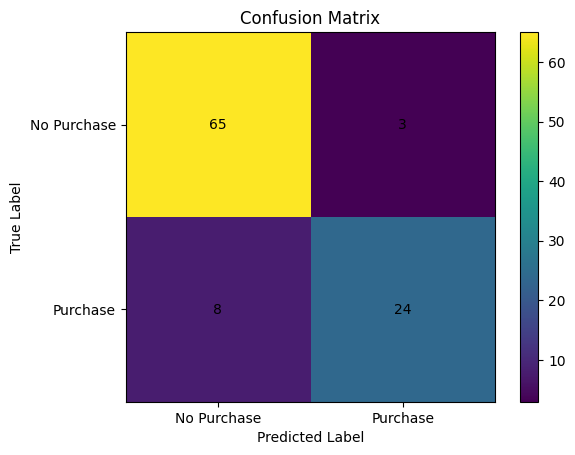

In [38]:
# Assuming you already have y_test and y_pred
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure()
plt.imshow(cm)

# Labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Tick marks
classes = ['No Purchase', 'Purchase']
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

# Add numbers inside boxes
for i in range(len(cm)):
  for j in range(len(cm)):
    plt.text(j, i, cm[i][j], ha="center", va="center")

plt.colorbar()
plt.show()